[NORMAL] Passos médios (eval): 100.00
[NORMAL] Taxa de sucesso (eval): 0.0%
[REMOVIDO] Passos médios (eval): 100.00
[REMOVIDO] Taxa de sucesso (eval): 0.0%


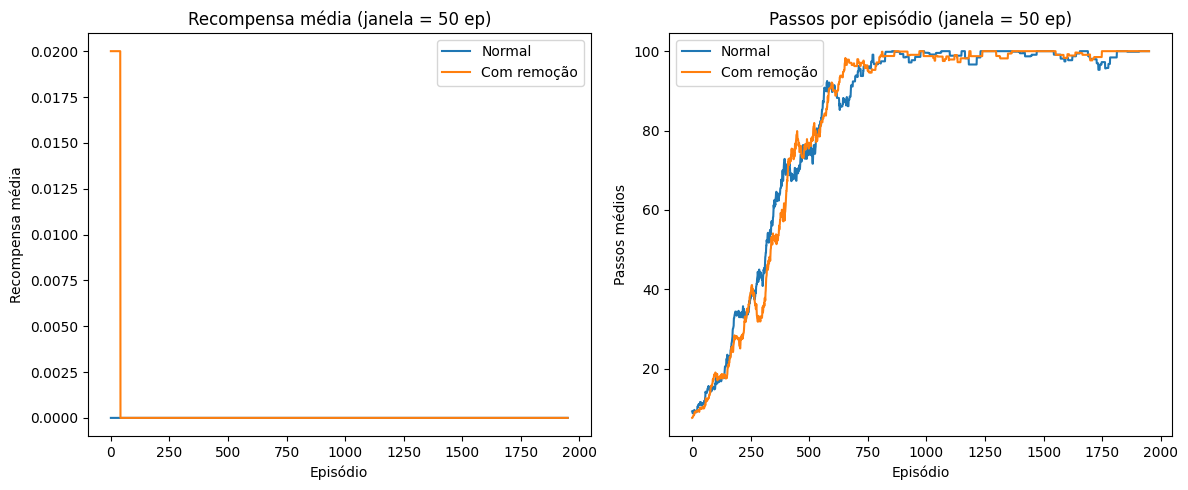

GIFs salvos como 'frozenlake_normal.gif' e 'frozenlake_blur.gif'


In [3]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import imageio
from typing import List, Tuple, Optional


# -----------------------------------
# Treino Q-Learning (tabular)
# -----------------------------------
def train_q_learning(
    env: gym.Env,
    episodes: int = 2000,
    alpha: float = 0.8,
    gamma: float = 0.95,
    epsilon: float = 1.0,
    epsilon_min: float = 0.01,
    epsilon_decay: float = 0.995,
) -> Tuple[np.ndarray, List[float], List[int]]:
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    q_table = np.zeros((n_states, n_actions))

    rewards_per_episode = []
    steps_per_episode = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0.0
        steps = 0

        while not done:
            # Política ε-greedy
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(q_table[state]))

            new_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Atualização Q-Learning
            q_table[state, action] = q_table[state, action] + alpha * (
                reward + gamma * np.max(q_table[new_state]) - q_table[state, action]
            )

            state = new_state
            total_reward += reward
            steps += 1

        epsilon = max(epsilon * epsilon_decay, epsilon_min)

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)

    return q_table, rewards_per_episode, steps_per_episode


# -----------------------------------
# Avaliação de uma política fixa (Q)
# -----------------------------------
def evaluate_policy(
    env: gym.Env, q_table: np.ndarray, episodes: int = 200
) -> Tuple[float, float]:
    steps_list = []
    successes = 0

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        steps = 0

        while not done:
            action = int(np.argmax(q_table[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1

            if done and reward > 0:
                successes += 1

        steps_list.append(steps)

    mean_steps = float(np.mean(steps_list))
    success_rate = successes / episodes
    return mean_steps, success_rate


# -----------------------------------
# Modificar ambiente (remoção de estados)
# -----------------------------------
def modify_environment(env: gym.Env, removed_states: List[int]) -> gym.Env:
    """
    Simula 'remoção' transformando certos estados em terminais neutros.
    Quando o agente entra em um estado removido, o episódio termina com reward = 0.
    """
    original_step = env.step  # guarda a função original

    def wrapped_step(action):
        state, reward, terminated, truncated, info = original_step(action)

        if state in removed_states:
            reward = 0.0
            terminated = True  # força fim do episódio

        return state, reward, terminated, truncated, info

    env.step = wrapped_step
    return env


# -----------------------------------
# Renderização visual do FrozenLake
# -----------------------------------
def render_frame(
    state: int,
    img_size: int = 256,
    removed_states: Optional[List[int]] = None,
    blur_region: Optional[Tuple[int, int, int, int]] = None,
    blur_mode: str = "blur",
) -> np.ndarray:
    """
    Gera uma imagem RGB do grid 4x4 do FrozenLake com o agente.
    removed_states: células que serão desenhadas em cinza (removidas).
    blur_region: (x0, y0, x1, y1) em pixels, para aplicar blur/oclusão.
    """

    n_rows, n_cols = 4, 4
    cell = img_size // n_rows

    frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)

    # Definição padrão de FrozenLake 4x4
    holes = {5, 7, 11, 12}
    goal = 15

    # Desenha o grid
    for r in range(n_rows):
        for c in range(n_cols):
            idx = r * n_cols + c
            y0, y1 = r * cell, (r + 1) * cell
            x0, x1 = c * cell, (c + 1) * cell

            if idx == goal:
                color = (0, 200, 0)          # verde para o goal
            elif idx in holes:
                color = (0, 0, 0)            # buracos em preto
            elif removed_states is not None and idx in removed_states:
                color = (80, 80, 80)         # estados removidos em cinza escuro
            else:
                color = (180, 220, 255)      # gelo/frozen em azul claro

            frame[y0:y1, x0:x1] = color

    # Desenha o agente como um quadradinho vermelho
    r_agent = state // n_cols
    c_agent = state % n_cols
    y0, y1 = r_agent * cell, (r_agent + 1) * cell
    x0, x1 = c_agent * cell, (c_agent + 1) * cell

    cy, cx = (y0 + y1) // 2, (x0 + x1) // 2
    radius = cell // 4
    frame[cy - radius : cy + radius, cx - radius : cx + radius] = (200, 50, 50)

    # Aplica blur/oclusão visual se solicitado
    if blur_region is not None:
        x0, y0, x1, y1 = blur_region
        x0 = max(0, x0)
        y0 = max(0, y0)
        x1 = min(img_size, x1)
        y1 = min(img_size, y1)

        patch = frame[y0:y1, x0:x1].astype(np.float32)
        if patch.size > 0:
            if blur_mode == "occlude":
                # Oclusão simples (caixa cinza)
                frame[y0:y1, x0:x1] = 128
            else:
                # "Blur" simples via downsample + upsample
                scale = 4
                h, w = patch.shape[:2]
                if h // scale > 0 and w // scale > 0:
                    patch_small = patch[::scale, ::scale]
                    patch_blur = np.repeat(
                        np.repeat(patch_small, scale, axis=0),
                        scale,
                        axis=1,
                    )
                    patch_blur = patch_blur[:h, :w, :]
                    frame[y0:y1, x0:x1] = patch_blur.astype(np.uint8)

    return frame


# -----------------------------------
# Gravar um episódio em vídeo (GIF)
# -----------------------------------
def record_episode(
    env: gym.Env,
    q_table: np.ndarray,
    removed_states: Optional[List[int]] = None,
    max_steps: int = 100,
    img_size: int = 256,
    blur_visual: bool = False,
    blur_mode: str = "blur",
) -> List[np.ndarray]:
    frames = []
    state, _ = env.reset()
    done = False

    # região borrada/ocluída no centro da tela
    blur_region = None
    if blur_visual:
        blur_region = (
            img_size // 4,
            img_size // 4,
            3 * img_size // 4,
            3 * img_size // 4,
        )

    for _ in range(max_steps):
        frame = render_frame(
            state,
            img_size=img_size,
            removed_states=removed_states,
            blur_region=blur_region,
            blur_mode=blur_mode,
        )
        frames.append(frame)

        action = int(np.argmax(q_table[state]))
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state

        if done:
            frame = render_frame(
                state,
                img_size=img_size,
                removed_states=removed_states,
                blur_region=blur_region,
                blur_mode=blur_mode,
            )
            frames.append(frame)
            break

    return frames


# -----------------------------------
# Execução do experimento completo
# -----------------------------------
if __name__ == "__main__":
    # ========= Ambiente base =========
    env = gym.make("FrozenLake-v1", is_slippery=False)

    # ----- Treino normal -----
    q_normal, r_normal, s_normal = train_q_learning(env)
    mean_steps_normal, success_normal = evaluate_policy(env, q_normal)

    print(f"[NORMAL] Passos médios (eval): {mean_steps_normal:.2f}")
    print(f"[NORMAL] Taxa de sucesso (eval): {success_normal*100:.1f}%")

    # ----- Treino com 'remoção' de estados -----
    removed_states = [5, 9]  # por exemplo, duas células intermediárias
    env_blur = gym.make("FrozenLake-v1", is_slippery=False)
    env_blur = modify_environment(env_blur, removed_states=removed_states)

    q_blur, r_blur, s_blur = train_q_learning(env_blur)
    mean_steps_blur, success_blur = evaluate_policy(env_blur, q_blur)

    print(f"[REMOVIDO] Passos médios (eval): {mean_steps_blur:.2f}")
    print(f"[REMOVIDO] Taxa de sucesso (eval): {success_blur*100:.1f}%")

    # ========= Gráficos de aprendizado =========
    window = 50
    kernel = np.ones(window) / window

    r_norm_smooth = np.convolve(r_normal, kernel, mode="valid")
    r_blur_smooth = np.convolve(r_blur, kernel, mode="valid")
    s_norm_smooth = np.convolve(s_normal, kernel, mode="valid")
    s_blur_smooth = np.convolve(s_blur, kernel, mode="valid")

    plt.figure(figsize=(12, 5))

    # Recompensa
    plt.subplot(1, 2, 1)
    plt.plot(r_norm_smooth, label="Normal")
    plt.plot(r_blur_smooth, label="Com remoção")
    plt.title("Recompensa média (janela = 50 ep)")
    plt.xlabel("Episódio")
    plt.ylabel("Recompensa média")
    plt.legend()

    # Passos por episódio
    plt.subplot(1, 2, 2)
    plt.plot(s_norm_smooth, label="Normal")
    plt.plot(s_blur_smooth, label="Com remoção")
    plt.title("Passos por episódio (janela = 50 ep)")
    plt.xlabel("Episódio")
    plt.ylabel("Passos médios")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # ========= Geração dos vídeos (GIFs) =========
    # Episódio típico com política ótima no ambiente normal
    env_vid_normal = gym.make("FrozenLake-v1", is_slippery=False)
    frames_normal = record_episode(
        env_vid_normal,
        q_normal,
        removed_states=None,
        img_size=256,
        blur_visual=False,
    )

    # Episódio típico no ambiente modificado + blur visual
    env_vid_blur = gym.make("FrozenLake-v1", is_slippery=False)
    env_vid_blur = modify_environment(env_vid_blur, removed_states=removed_states)
    frames_blur = record_episode(
        env_vid_blur,
        q_blur,
        removed_states=removed_states,
        img_size=256,
        blur_visual=True,   # aqui aplicamos o blur visual
        blur_mode="blur",   # ou "occlude" se quiser só tampar
    )

    # Salva como GIF
    imageio.mimsave("frozenlake_normal.gif", frames_normal, duration=0.2)
    imageio.mimsave("frozenlake_blur.gif", frames_blur, duration=0.2)

    print("GIFs salvos como 'frozenlake_normal.gif' e 'frozenlake_blur.gif'")



In [3]:
import os
from typing import Tuple, List, Optional

import numpy as np
import gymnasium as gym
import imageio
from PIL import Image, ImageDraw

# ==========================
# Configs globais de vídeo
# ==========================

GIF_DURATION_POLICY = 0.12    # segundos por frame (política final)
GIF_DURATION_LEARNING = 0.07  # segundos por frame (vídeo de aprendizado)
FRAME_SKIP_LEARNING = 3       # grava 1 frame a cada N steps no aprendizado


# ============================================================
# Auxiliares: ε-greedy, texto no frame
# ============================================================

def epsilon_greedy(q_table: np.ndarray, state: int, epsilon: float, n_actions: int) -> int:
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(q_table[state]))


def add_title(
    frame: np.ndarray,
    algo_name: str,
    ep: Optional[int] = None,
    step: Optional[int] = None
) -> np.ndarray:
    """Adiciona barra preta no topo com nome do algoritmo + (ep, step)."""
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)
    w, h = img.size

    bar_h = int(h * 0.10)
    draw.rectangle([0, 0, w, bar_h], fill=(0, 0, 0))

    if ep is not None and step is not None:
        text = f"{algo_name} | ep {ep} | step {step}"
    elif ep is not None:
        text = f"{algo_name} | ep {ep}"
    else:
        text = algo_name

    draw.text((5, 2), text, fill=(255, 255, 255))
    return np.array(img)


# ============================================================
# WRAPPERS: estados/células removidos como terminais
# ============================================================

class RemovedStatesCliffWrapper(gym.Wrapper):
    """
    CliffWalking: certos estados (índices) são 'removidos' e viram terminais neutros.
    """
    def __init__(self, env, removed_states, terminal_reward: float = 0.0):
        super().__init__(env)
        self.removed_states = set(removed_states)
        self.terminal_reward = terminal_reward

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if (obs in self.removed_states) and not (terminated or truncated):
            reward = self.terminal_reward
            terminated = True
        return obs, reward, terminated, truncated, info


class RemovedCellsTaxiWrapper(gym.Wrapper):
    """
    Taxi: certas células (linha,coluna) são 'removidas' e viram terminais.
    """
    def __init__(self, env, removed_cells, terminal_reward: float = -2.0):
        super().__init__(env)
        self.removed_cells = set(removed_cells)
        self.terminal_reward = terminal_reward

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        taxi_row, taxi_col, pass_loc, dest_idx = self.env.unwrapped.decode(obs)
        if (taxi_row, taxi_col) in self.removed_cells and not (terminated or truncated):
            reward = self.terminal_reward
            terminated = True
        return obs, reward, terminated, truncated, info


# ============================================================
# Funções de sucesso por ambiente
# ============================================================

def make_cliff_success_fn(removed_states: Optional[List[int]] = None,
                          rows: int = 4, cols: int = 12):
    """
    Sucesso em CliffWalking = chegar no goal (último estado da grade),
    desde que não seja um estado removido.
    """
    goal_state = rows * cols - 1
    removed = set(removed_states or [])

    def success_fn(state: int, reward: float, terminated: bool, truncated: bool) -> bool:
        if not terminated or truncated:
            return False
        if state in removed:
            return False
        return state == goal_state

    return success_fn


def taxi_success_fn(state: int, reward: float, terminated: bool, truncated: bool) -> bool:
    """
    Sucesso em Taxi = episódio termina com recompensa positiva (dropoff correto).
    """
    return terminated and not truncated and (reward > 0)


# ============================================================
# RENDER: CliffWalking
# ============================================================

def render_cliff_frame(
    state: int,
    removed_states: Optional[List[int]] = None,
    img_width: int = 480,
    img_height: int = 160,
) -> np.ndarray:
    rows, cols = 4, 12
    cell_w = img_width // cols
    cell_h = img_height // rows
    frame = np.zeros((img_height, img_width, 3), dtype=np.uint8)

    start = (3, 0)
    goal = (3, 11)
    cliff_cells = {(3, c) for c in range(1, 11)}
    removed_states = set(removed_states or [])

    for r in range(rows):
        for c in range(cols):
            y0, y1 = r * cell_h, (r + 1) * cell_h
            x0, x1 = c * cell_w, (c + 1) * cell_w
            idx = r * cols + c

            if (r, c) == start:
                color = (0, 0, 200)      # início
            elif (r, c) == goal:
                color = (0, 180, 0)      # goal
            elif (r, c) in cliff_cells:
                color = (0, 0, 0)        # penhasco
            elif idx in removed_states:
                color = (120, 120, 120)  # removido
            else:
                color = (220, 220, 220)  # chão

            frame[y0:y1, x0:x1] = color
            # grades
            frame[y0:y1, x0:x0+1] = 0
            frame[y0:y1, x1-1:x1] = 0
            frame[y0:y0+1, x0:x1] = 0
            frame[y1-1:y1, x0:x1] = 0

    r_agent = state // cols
    c_agent = state % cols
    y0, y1 = r_agent * cell_h, (r_agent + 1) * cell_h
    x0, x1 = c_agent * cell_w, (c_agent + 1) * cell_w
    cy, cx = (y0 + y1) // 2, (x0 + x1) // 2
    radius = min(cell_w, cell_h) // 4
    frame[cy-radius:cy+radius, cx-radius:cx+radius] = (200, 50, 50)  # agente
    return frame


# ============================================================
# RENDER: Taxi
# ============================================================

def render_taxi_frame(
    env: gym.Env,
    state: int,
    removed_cells: Optional[List[Tuple[int, int]]] = None,
    img_size: int = 256,
) -> np.ndarray:
    rows, cols = 5, 5
    cell = img_size // rows
    frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
    frame[:, :] = (245, 245, 245)

    taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(state)
    locs = env.unwrapped.locs
    removed_cells = set(removed_cells or [])

    # grid + removidos
    for r in range(rows):
        for c in range(cols):
            y0, y1 = r * cell, (r + 1) * cell
            x0, x1 = c * cell, (c + 1) * cell
            if (r, c) in removed_cells:
                frame[y0:y1, x0:x1] = (160, 160, 160)  # célula removida
            frame[y0:y1, x0:x0+1] = 0
            frame[y0:y1, x1-1:x1] = 0
            frame[y0:y0+1, x0:x1] = 0
            frame[y1-1:y1, x0:x1] = 0

    # pontos R,G,B,Y
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
    for idx, (r, c) in enumerate(locs):
        y0, y1 = r * cell, (r + 1) * cell
        x0, x1 = c * cell, (c + 1) * cell
        frame[y0:y1, x0:x1] = colors[idx]

    # destino -> borda verde escura
    dest_r, dest_c = locs[dest_idx]
    y0, y1 = dest_r * cell, (dest_r + 1) * cell
    x0, x1 = dest_c * cell, (dest_c + 1) * cell
    frame[y0:y1, x0:x0+2] = (0, 128, 0)
    frame[y0:y1, x1-2:x1] = (0, 128, 0)
    frame[y0:y0+2, x0:x1] = (0, 128, 0)
    frame[y1-2:y1, x0:x1] = (0, 128, 0)

    # passageiro
    if pass_loc < 4:
        pr, pc = locs[pass_loc]
        cy, cx = (pr * cell + cell // 2), (pc * cell + cell // 2)
    else:
        cy, cx = (taxi_row * cell + cell // 2), (taxi_col * cell + cell // 2)
    r_p = cell // 6
    frame[cy-r_p:cy+r_p, cx-r_p:cx+r_p] = (50, 50, 200)

    # táxi
    y0, y1 = taxi_row * cell, (taxi_row + 1) * cell
    x0, x1 = taxi_col * cell, (taxi_col + 1) * cell
    margin = cell // 6
    frame[y0+margin:y1-margin, x0+margin:x1-margin] = (255, 215, 0)

    return frame


# ============================================================
# Genérico: grava UM episódio com política final
# ============================================================

def record_episode(
    env: gym.Env,
    policy: np.ndarray,
    algo_name: str,
    render_fn,
    max_steps: int = 200,
) -> List[np.ndarray]:
    frames = []
    state, _ = env.reset()
    for t in range(max_steps):
        frame = render_fn(env, state)
        frame = add_title(frame, algo_name, ep=1, step=t)
        frames.append(frame)

        action = int(policy[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        if terminated or truncated:
            frame = render_fn(env, state)
            frame = add_title(frame, algo_name, ep=1, step=t+1)
            frames.append(frame)
            break
    return frames


# ============================================================
# Avaliação offline de política (usa success_fn)
# ============================================================

def evaluate_policy(
    env: gym.Env,
    policy: np.ndarray,
    success_fn,
    episodes: int = 100,
    max_steps: int = 200,
) -> Tuple[float, float, float, int]:
    total_steps, total_rewards = [], []
    successes = 0
    first_success_ep = -1

    for ep in range(episodes):
        state, _ = env.reset()
        ep_reward = 0.0
        steps = 0

        for t in range(max_steps):
            action = int(policy[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            steps += 1
            state = next_state

            if terminated or truncated:
                if success_fn(state, reward, terminated, truncated):
                    successes += 1
                    if first_success_ep == -1:
                        first_success_ep = ep + 1
                break

        total_steps.append(steps)
        total_rewards.append(ep_reward)

    mean_steps = float(np.mean(total_steps))
    mean_reward = float(np.mean(total_rewards))
    success_rate = successes / episodes
    return mean_steps, success_rate, mean_reward, first_success_ep


# ============================================================
# DP: Value Iteration com vídeo (para assim que resolver)
# ============================================================

def value_iteration_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    success_fn,
    sweeps: int = 40,
    gamma: float = 0.99,
    theta: float = 1e-6,
    max_steps_episode: int = 100,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    P = env.unwrapped.P

    V = np.zeros(n_states)
    policy = np.zeros(n_states, dtype=int)

    frames = []
    sweep_rewards, sweep_steps = [], []
    first_success_sweep = -1

    for sweep in range(1, sweeps + 1):
        # iteração de valor
        while True:
            delta = 0.0
            for s in range(n_states):
                v_old = V[s]
                q_vals = np.zeros(n_actions)
                for a in range(n_actions):
                    for prob, s_next, reward, done in P[s][a]:
                        q_vals[a] += prob * (reward + gamma * (0 if done else V[s_next]))
                V[s] = np.max(q_vals)
                delta = max(delta, abs(v_old - V[s]))
            if delta < theta:
                break

        # política gulosa atual
        for s in range(n_states):
            q_vals = np.zeros(n_actions)
            for a in range(n_actions):
                for prob, s_next, reward, done in P[s][a]:
                    q_vals[a] += prob * (reward + gamma * (0 if done else V[s_next]))
            policy[s] = int(np.argmax(q_vals))

        # 1 episódio para visualização e checar sucesso
        state, _ = env.reset()
        ep_reward = 0.0
        steps = 0
        success_this_sweep = False

        for t in range(max_steps_episode):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=sweep, step=t)
                frames.append(frame)

            action = int(policy[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            steps += 1
            state = next_state

            if terminated or truncated:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=sweep, step=t + 1)
                frames.append(frame)
                if success_fn(state, reward, terminated, truncated):
                    success_this_sweep = True
                    if first_success_sweep == -1:
                        first_success_sweep = sweep
                break

        sweep_rewards.append(ep_reward)
        sweep_steps.append(steps)

        # >>> PARAR QUANDO RESOLVER
        if success_this_sweep:
            break

    stats = {
        "mean_reward": float(np.mean(sweep_rewards)),
        "mean_steps": float(np.mean(sweep_steps)),
        "episodes_run": len(sweep_rewards),
        "first_success_ep": first_success_sweep,
    }
    return policy, frames, stats


# ============================================================
# SARSA / Q-Learning com vídeo (param cedo ao resolver)
# ============================================================

def sarsa_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    success_fn,
    episodes: int = 600,
    alpha: float = 0.1,
    gamma: float = 0.99,
    epsilon_start: float = 1.0,
    epsilon_min: float = 0.05,
    epsilon_decay: float = 0.995,
    max_steps: int = 200,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q_table = np.zeros((n_states, n_actions))
    frames = []
    ep_rewards, ep_steps = [], []
    first_success_ep = -1
    epsilon = epsilon_start

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        action = epsilon_greedy(q_table, state, epsilon, n_actions)
        ep_reward = 0.0
        steps = 0
        success_this_ep = False

        for t in range(max_steps):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t)
                frames.append(frame)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_action = epsilon_greedy(q_table, next_state, epsilon, n_actions)
            td_target = reward + gamma * q_table[next_state, next_action] * (0 if done else 1)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            ep_reward += reward
            steps += 1
            state, action = next_state, next_action

            if done:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t + 1)
                frames.append(frame)
                if success_fn(state, reward, terminated, truncated):
                    success_this_ep = True
                    if first_success_ep == -1:
                        first_success_ep = ep
                break

        ep_rewards.append(ep_reward)
        ep_steps.append(steps)
        epsilon = max(epsilon * epsilon_decay, epsilon_min)

        # >>> PARAR QUANDO RESOLVER
        if success_this_ep:
            break

    policy = np.argmax(q_table, axis=1)
    stats = {
        "mean_reward": float(np.mean(ep_rewards)),
        "mean_steps": float(np.mean(ep_steps)),
        "episodes_run": len(ep_rewards),
        "first_success_ep": first_success_ep,
    }
    return policy, frames, stats


def q_learning_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    success_fn,
    episodes: int = 600,
    alpha: float = 0.1,
    gamma: float = 0.99,
    epsilon_start: float = 1.0,
    epsilon_min: float = 0.05,
    epsilon_decay: float = 0.995,
    max_steps: int = 200,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q_table = np.zeros((n_states, n_actions))
    frames = []
    ep_rewards, ep_steps = [], []
    first_success_ep = -1
    epsilon = epsilon_start

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        ep_reward = 0.0
        steps = 0
        success_this_ep = False

        for t in range(max_steps):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t)
                frames.append(frame)

            action = epsilon_greedy(q_table, state, epsilon, n_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            best_next = np.max(q_table[next_state])
            td_target = reward + gamma * best_next * (0 if done else 1)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            ep_reward += reward
            steps += 1
            state = next_state

            if done:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t + 1)
                frames.append(frame)
                if success_fn(state, reward, terminated, truncated):
                    success_this_ep = True
                    if first_success_ep == -1:
                        first_success_ep = ep
                break

        ep_rewards.append(ep_reward)
        ep_steps.append(steps)
        epsilon = max(epsilon * epsilon_decay, epsilon_min)

        # >>> PARAR QUANDO RESOLVER
        if success_this_ep:
            break

    policy = np.argmax(q_table, axis=1)
    stats = {
        "mean_reward": float(np.mean(ep_rewards)),
        "mean_steps": float(np.mean(ep_steps)),
        "episodes_run": len(ep_rewards),
        "first_success_ep": first_success_ep,
    }
    return policy, frames, stats


# ============================================================
# MAIN: roda tudo
# ============================================================

def run_all():
    np.random.seed(0)

    base_video_dir = "video"
    os.makedirs(base_video_dir, exist_ok=True)

    cliff_id = "CliffWalking-v1"
    taxi_id = "Taxi-v3"

    cliff_dir = os.path.join(base_video_dir, cliff_id)
    taxi_dir = os.path.join(base_video_dir, taxi_id)
    os.makedirs(cliff_dir, exist_ok=True)
    os.makedirs(taxi_dir, exist_ok=True)

    # estados removidos (Cliff) e células removidas (Taxi)
    cliff_removed_states = [2 * 12 + c for c in range(3, 9)]
    taxi_removed_cells = [(2, 2), (3, 3)]

    # só DP, SARSA, QL
    algos = ["DP", "SARSA", "QL"]

    # success functions
    success_cliff = make_cliff_success_fn(None)
    success_cliff_removed = make_cliff_success_fn(cliff_removed_states)
    success_taxi = taxi_success_fn  # mesma para original e removed

    # ===================== CLIFF ORIGINAL =====================
    print("===== CLIFFWALKING ORIGINAL =====")
    for algo in algos:
        print(f"\n{algo} - Cliff original")
        env = gym.make(cliff_id)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=None),
                "ValueIteration",
                success_cliff,
                sweeps=30
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=None),
                "SARSA",
                success_cliff
            )
        else:  # QL
            policy, frames_learn, stats = q_learning_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=None),
                "Q-Learning",
                success_cliff
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(cliff_dir, f"{algo}_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = gym.make(cliff_id)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(
            env_eval, policy, success_cliff
        )
        print("eval:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = gym.make(cliff_id)
        frames_policy = record_episode(
            env_video,
            policy,
            f"{algo}_policy",
            lambda e, s: render_cliff_frame(s, removed_states=None)
        )
        gif_policy = os.path.join(cliff_dir, f"{algo}.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)

    # ===================== CLIFF REMOVED =====================
    print("\n===== CLIFFWALKING REMOVED =====")
    for algo in algos:
        print(f"\n{algo} - Cliff removed")
        env = RemovedStatesCliffWrapper(gym.make(cliff_id), cliff_removed_states, terminal_reward=0.0)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "ValueIteration_removed",
                success_cliff_removed,
                sweeps=30
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "SARSA_removed",
                success_cliff_removed
            )
        else:
            policy, frames_learn, stats = q_learning_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "Q-Learning_removed",
                success_cliff_removed
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(cliff_dir, f"{algo}_removed_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = RemovedStatesCliffWrapper(gym.make(cliff_id), cliff_removed_states, terminal_reward=0.0)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(
            env_eval, policy, success_cliff_removed
        )
        print("eval removed:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = RemovedStatesCliffWrapper(gym.make(cliff_id), cliff_removed_states, terminal_reward=0.0)
        frames_policy = record_episode(
            env_video,
            policy,
            f"{algo}_policy_removed",
            lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states)
        )
        gif_policy = os.path.join(cliff_dir, f"{algo}_removed.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)

    # ===================== TAXI ORIGINAL =====================
    print("\n===== TAXI ORIGINAL =====")
    for algo in algos:
        print(f"\n{algo} - Taxi original")
        env = gym.make(taxi_id)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "ValueIteration_taxi",
                success_taxi,
                sweeps=30,
                max_steps_episode=80
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "SARSA_taxi",
                success_taxi,
                max_steps=80
            )
        else:
            policy, frames_learn, stats = q_learning_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "Q-Learning_taxi",
                success_taxi,
                max_steps=80
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(taxi_dir, f"{algo}_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = gym.make(taxi_id)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(
            env_eval, policy, success_taxi, max_steps=80
        )
        print("eval taxi:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = gym.make(taxi_id)
        frames_policy = record_episode(
            env_video,
            policy,
            f"{algo}_policy_taxi",
            lambda e, s: render_taxi_frame(e, s, removed_cells=None),
            max_steps=80,
        )
        gif_policy = os.path.join(taxi_dir, f"{algo}.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)

    # ===================== TAXI REMOVED =====================
    print("\n===== TAXI REMOVED =====")
    for algo in algos:
        print(f"\n{algo} - Taxi removed")
        env = RemovedCellsTaxiWrapper(gym.make(taxi_id), taxi_removed_cells, terminal_reward=-2.0)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "ValueIteration_taxi_removed",
                success_taxi,
                sweeps=30,
                max_steps_episode=80
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "SARSA_taxi_removed",
                success_taxi,
                max_steps=80
            )
        else:
            policy, frames_learn, stats = q_learning_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "Q-Learning_taxi_removed",
                success_taxi,
                max_steps=80
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(taxi_dir, f"{algo}_removed_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = RemovedCellsTaxiWrapper(gym.make(taxi_id), taxi_removed_cells, terminal_reward=-2.0)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(
            env_eval, policy, success_taxi, max_steps=80
        )
        print("eval taxi removed:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = RemovedCellsTaxiWrapper(gym.make(taxi_id), taxi_removed_cells, terminal_reward=-2.0)
        frames_policy = record_episode(
            env_video,
            policy,
            f"{algo}_policy_taxi_removed",
            lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
            max_steps=80,
        )
        gif_policy = os.path.join(taxi_dir, f"{algo}_removed.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)


if __name__ == "__main__":
    run_all()


===== CLIFFWALKING ORIGINAL =====

DP - Cliff original
stats (treino): {'mean_reward': -13.0, 'mean_steps': 13.0, 'episodes_run': 1, 'first_success_ep': 1}
eval: 13.0 1.0 -13.0 1

SARSA - Cliff original
stats (treino): {'mean_reward': -1590.5142857142857, 'mean_steps': 196.02857142857144, 'episodes_run': 35, 'first_success_ep': 35}
eval: 200.0 0.0 -200.0 -1

QL - Cliff original
stats (treino): {'mean_reward': -1799.590909090909, 'mean_steps': 197.5909090909091, 'episodes_run': 22, 'first_success_ep': 22}
eval: 200.0 0.0 -200.0 -1

===== CLIFFWALKING REMOVED =====

DP - Cliff removed
stats (treino): {'mean_reward': -3.0, 'mean_steps': 4.0, 'episodes_run': 30, 'first_success_ep': -1}
eval removed: 4.0 0.0 -3.0 -1

SARSA - Cliff removed
stats (treino): {'mean_reward': -49.20166666666667, 'mean_steps': 14.066666666666666, 'episodes_run': 600, 'first_success_ep': -1}
eval removed: 8.0 0.0 -7.0 -1

QL - Cliff removed
stats (treino): {'mean_reward': -75.50166666666667, 'mean_steps': 11.158333

In [5]:
import os
from typing import Tuple, List, Optional

import numpy as np
import gymnasium as gym
import imageio
from PIL import Image, ImageDraw

# ==========================
# Configs globais de vídeo
# ==========================

GIF_DURATION_POLICY = 0.12    # política final
GIF_DURATION_LEARNING = 0.07  # vídeo de aprendizado
FRAME_SKIP_LEARNING = 3       # grava 1 frame a cada N steps


# ============================================================
# Auxiliares: ε-greedy, texto no frame
# ============================================================

def epsilon_greedy(q_table: np.ndarray, state: int, epsilon: float, n_actions: int) -> int:
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(q_table[state]))


def add_title(
    frame: np.ndarray,
    algo_name: str,
    ep: Optional[int] = None,
    step: Optional[int] = None
) -> np.ndarray:
    """Adiciona barra preta no topo com nome do algoritmo + (ep, step)."""
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)
    w, h = img.size

    bar_h = int(h * 0.10)
    draw.rectangle([0, 0, w, bar_h], fill=(0, 0, 0))

    if ep is not None and step is not None:
        text = f"{algo_name} | ep {ep} | step {step}"
    elif ep is not None:
        text = f"{algo_name} | ep {ep}"
    else:
        text = algo_name

    draw.text((5, 2), text, fill=(255, 255, 255))
    return np.array(img)


# ============================================================
# WRAPPERS: estados/células removidos como terminais
# ============================================================

class RemovedStatesCliffWrapper(gym.Wrapper):
    """
    CliffWalking: certos estados (índices) são 'removidos' e viram terminais neutros.
    """
    def __init__(self, env, removed_states, terminal_reward: float = 0.0):
        super().__init__(env)
        self.removed_states = set(removed_states)
        self.terminal_reward = terminal_reward

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if (obs in self.removed_states) and not (terminated or truncated):
            reward = self.terminal_reward
            terminated = True
        return obs, reward, terminated, truncated, info


class RemovedCellsTaxiWrapper(gym.Wrapper):
    """
    Taxi: certas células (linha,coluna) são 'removidas' e viram terminais.
    """
    def __init__(self, env, removed_cells, terminal_reward: float = -2.0):
        super().__init__(env)
        self.removed_cells = set(removed_cells)
        self.terminal_reward = terminal_reward

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        taxi_row, taxi_col, pass_loc, dest_idx = self.env.unwrapped.decode(obs)
        if (taxi_row, taxi_col) in self.removed_cells and not (terminated or truncated):
            reward = self.terminal_reward
            terminated = True
        return obs, reward, terminated, truncated, info


# ============================================================
# RENDER: CliffWalking
# ============================================================

def render_cliff_frame(
    state: int,
    removed_states: Optional[List[int]] = None,
    img_width: int = 480,
    img_height: int = 160,
) -> np.ndarray:
    rows, cols = 4, 12
    cell_w = img_width // cols
    cell_h = img_height // rows
    frame = np.zeros((img_height, img_width, 3), dtype=np.uint8)

    start = (3, 0)
    goal = (3, 11)
    cliff_cells = {(3, c) for c in range(1, 11)}
    removed_states = set(removed_states or [])

    for r in range(rows):
        for c in range(cols):
            y0, y1 = r * cell_h, (r + 1) * cell_h
            x0, x1 = c * cell_w, (c + 1) * cell_w
            idx = r * cols + c

            if (r, c) == start:
                color = (0, 0, 200)      # início
            elif (r, c) == goal:
                color = (0, 180, 0)      # goal
            elif (r, c) in cliff_cells:
                color = (0, 0, 0)        # penhasco
            elif idx in removed_states:
                color = (120, 120, 120)  # removido
            else:
                color = (220, 220, 220)  # chão

            frame[y0:y1, x0:x1] = color
            # grades
            frame[y0:y1, x0:x0+1] = 0
            frame[y0:y1, x1-1:x1] = 0
            frame[y0:y0+1, x0:x1] = 0
            frame[y1-1:y1, x0:x1] = 0

    r_agent = state // cols
    c_agent = state % cols
    y0, y1 = r_agent * cell_h, (r_agent + 1) * cell_h
    x0, x1 = c_agent * cell_w, (c_agent + 1) * cell_w
    cy, cx = (y0 + y1) // 2, (x0 + x1) // 2
    radius = min(cell_w, cell_h) // 4
    frame[cy-radius:cy+radius, cx-radius:cx+radius] = (200, 50, 50)  # agente
    return frame


# ============================================================
# RENDER: Taxi
# ============================================================

def render_taxi_frame(
    env: gym.Env,
    state: int,
    removed_cells: Optional[List[Tuple[int, int]]] = None,
    img_size: int = 256,
) -> np.ndarray:
    rows, cols = 5, 5
    cell = img_size // rows
    frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
    frame[:, :] = (245, 245, 245)

    taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(state)
    locs = env.unwrapped.locs
    removed_cells = set(removed_cells or [])

    # grid + removidos
    for r in range(rows):
        for c in range(cols):
            y0, y1 = r * cell, (r + 1) * cell
            x0, x1 = c * cell, (c + 1) * cell
            if (r, c) in removed_cells:
                frame[y0:y1, x0:x1] = (160, 160, 160)  # célula removida
            frame[y0:y1, x0:x0+1] = 0
            frame[y0:y1, x1-1:x1] = 0
            frame[y0:y0+1, x0:x1] = 0
            frame[y1-1:y1, x0:x1] = 0

    # pontos R,G,B,Y
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
    for idx, (r, c) in enumerate(locs):
        y0, y1 = r * cell, (r + 1) * cell
        x0, x1 = c * cell, (c + 1) * cell
        frame[y0:y1, x0:x1] = colors[idx]

    # destino -> borda verde escura
    dest_r, dest_c = locs[dest_idx]
    y0, y1 = dest_r * cell, (dest_r + 1) * cell
    x0, x1 = dest_c * cell, (dest_c + 1) * cell
    frame[y0:y1, x0:x0+2] = (0, 128, 0)
    frame[y0:y1, x1-2:x1] = (0, 128, 0)
    frame[y0:y0+2, x0:x1] = (0, 128, 0)
    frame[y1-2:y1, x0:x1] = (0, 128, 0)

    # passageiro
    if pass_loc < 4:
        pr, pc = locs[pass_loc]
        cy, cx = (pr * cell + cell // 2), (pc * cell + cell // 2)
    else:
        cy, cx = (taxi_row * cell + cell // 2), (taxi_col * cell + cell // 2)
    r_p = cell // 6
    frame[cy-r_p:cy+r_p, cx-r_p:cx+r_p] = (50, 50, 200)

    # táxi
    y0, y1 = taxi_row * cell, (taxi_row + 1) * cell
    x0, x1 = taxi_col * cell, (taxi_col + 1) * cell
    margin = cell // 6
    frame[y0+margin:y1-margin, x0+margin:x1-margin] = (255, 215, 0)

    return frame


# ============================================================
# Genérico: grava UM episódio com política final
# ============================================================

def record_episode(
    env: gym.Env,
    policy: np.ndarray,
    algo_name: str,
    render_fn,
    max_steps: int = 200,
) -> List[np.ndarray]:
    frames = []
    state, _ = env.reset()
    for t in range(max_steps):
        frame = render_fn(env, state)
        frame = add_title(frame, algo_name, ep=1, step=t)
        frames.append(frame)

        action = int(policy[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        if terminated or truncated:
            frame = render_fn(env, state)
            frame = add_title(frame, algo_name, ep=1, step=t+1)
            frames.append(frame)
            break
    return frames


# ============================================================
# Avaliação offline de política
# ============================================================

def evaluate_policy(
    env: gym.Env,
    policy: np.ndarray,
    episodes: int = 100,
    max_steps: int = 200,
) -> Tuple[float, float, float, int]:
    total_steps, total_rewards = [], []
    successes = 0
    first_success_ep = -1

    for ep in range(episodes):
        state, _ = env.reset()
        ep_reward = 0.0
        steps = 0

        for t in range(max_steps):
            action = int(policy[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            steps += 1
            state = next_state

            if terminated or truncated:
                if reward > 0:
                    successes += 1
                    if first_success_ep == -1:
                        first_success_ep = ep + 1
                break

        total_steps.append(steps)
        total_rewards.append(ep_reward)

    mean_steps = float(np.mean(total_steps))
    mean_reward = float(np.mean(total_rewards))
    success_rate = successes / episodes
    return mean_steps, success_rate, mean_reward, first_success_ep


# ============================================================
# DP: Value Iteration com vídeo
# ============================================================

def value_iteration_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    sweeps: int = 40,
    gamma: float = 0.99,
    theta: float = 1e-6,
    max_steps_episode: int = 100,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    P = env.unwrapped.P

    V = np.zeros(n_states)
    policy = np.zeros(n_states, dtype=int)

    frames = []
    sweep_rewards, sweep_steps = [], []
    first_success_sweep = -1

    for sweep in range(1, sweeps + 1):
        # iteração de valor até convergir para esse sweep
        while True:
            delta = 0.0
            for s in range(n_states):
                v_old = V[s]
                q_vals = np.zeros(n_actions)
                for a in range(n_actions):
                    for prob, s_next, reward, done in P[s][a]:
                        q_vals[a] += prob * (reward + gamma * (0 if done else V[s_next]))
                V[s] = np.max(q_vals)
                delta = max(delta, abs(v_old - V[s]))
            if delta < theta:
                break

        # política gulosa atual
        for s in range(n_states):
            q_vals = np.zeros(n_actions)
            for a in range(n_actions):
                for prob, s_next, reward, done in P[s][a]:
                    q_vals[a] += prob * (reward + gamma * (0 if done else V[s_next]))
            policy[s] = int(np.argmax(q_vals))

        # 1 episódio para visualização dessa política
        state, _ = env.reset()
        ep_reward = 0.0
        steps = 0

        for t in range(max_steps_episode):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=sweep, step=t)
                frames.append(frame)

            action = int(policy[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            steps += 1
            state = next_state

            if terminated or truncated:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=sweep, step=t + 1)
                frames.append(frame)
                if reward > 0 and first_success_sweep == -1:
                    first_success_sweep = sweep
                break

        sweep_rewards.append(ep_reward)
        sweep_steps.append(steps)

    stats = {
        "mean_reward": float(np.mean(sweep_rewards)),
        "mean_steps": float(np.mean(sweep_steps)),
        "episodes_run": sweeps,
        "first_success_ep": first_success_sweep,
    }
    return policy, frames, stats


# ============================================================
# MC / SARSA / Q-Learning com vídeo
# ============================================================

def monte_carlo_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    episodes: int = 400,
    gamma: float = 0.99,
    epsilon: float = 0.2,
    max_steps: int = 200,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q_table = np.zeros((n_states, n_actions))
    returns_sum = np.zeros_like(q_table)
    returns_count = np.zeros_like(q_table)

    frames = []
    ep_rewards, ep_steps = [], []
    first_success_ep = -1

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        episode_data = []
        ep_reward = 0.0
        steps = 0

        for t in range(max_steps):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t)
                frames.append(frame)

            action = epsilon_greedy(q_table, state, epsilon, n_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)

            episode_data.append((state, action, reward))
            ep_reward += reward
            steps += 1
            state = next_state

            if terminated or truncated:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t + 1)
                frames.append(frame)
                if reward > 0 and first_success_ep == -1:
                    first_success_ep = ep
                break

        ep_rewards.append(ep_reward)
        ep_steps.append(steps)

        # atualiza retornos (first-visit)
        G = 0.0
        visited = set()
        for t in reversed(range(len(episode_data))):
            s_t, a_t, r_t = episode_data[t]
            G = gamma * G + r_t
            if (s_t, a_t) not in visited:
                visited.add((s_t, a_t))
                returns_sum[s_t, a_t] += G
                returns_count[s_t, a_t] += 1.0
                q_table[s_t, a_t] = returns_sum[s_t, a_t] / returns_count[s_t, a_t]

    policy = np.argmax(q_table, axis=1)
    stats = {
        "mean_reward": float(np.mean(ep_rewards)),
        "mean_steps": float(np.mean(ep_steps)),
        "episodes_run": episodes,
        "first_success_ep": first_success_ep,
    }
    return policy, frames, stats


def sarsa_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    episodes: int = 600,
    alpha: float = 0.1,
    gamma: float = 0.99,
    epsilon_start: float = 1.0,
    epsilon_min: float = 0.05,
    epsilon_decay: float = 0.995,
    max_steps: int = 200,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q_table = np.zeros((n_states, n_actions))
    frames = []
    ep_rewards, ep_steps = [], []
    first_success_ep = -1
    epsilon = epsilon_start

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        action = epsilon_greedy(q_table, state, epsilon, n_actions)
        ep_reward = 0.0
        steps = 0

        for t in range(max_steps):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t)
                frames.append(frame)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_action = epsilon_greedy(q_table, next_state, epsilon, n_actions)
            td_target = reward + gamma * q_table[next_state, next_action] * (0 if done else 1)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            ep_reward += reward
            steps += 1
            state, action = next_state, next_action

            if done:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t + 1)
                frames.append(frame)
                if reward > 0 and first_success_ep == -1:
                    first_success_ep = ep
                break

        ep_rewards.append(ep_reward)
        ep_steps.append(steps)
        epsilon = max(epsilon * epsilon_decay, epsilon_min)

    policy = np.argmax(q_table, axis=1)
    stats = {
        "mean_reward": float(np.mean(ep_rewards)),
        "mean_steps": float(np.mean(ep_steps)),
        "episodes_run": episodes,
        "first_success_ep": first_success_ep,
    }
    return policy, frames, stats


def q_learning_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    episodes: int = 600,
    alpha: float = 0.1,
    gamma: float = 0.99,
    epsilon_start: float = 1.0,
    epsilon_min: float = 0.05,
    epsilon_decay: float = 0.995,
    max_steps: int = 200,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q_table = np.zeros((n_states, n_actions))
    frames = []
    ep_rewards, ep_steps = [], []
    first_success_ep = -1
    epsilon = epsilon_start

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        ep_reward = 0.0
        steps = 0

        for t in range(max_steps):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t)
                frames.append(frame)

            action = epsilon_greedy(q_table, state, epsilon, n_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            best_next = np.max(q_table[next_state])
            td_target = reward + gamma * best_next * (0 if done else 1)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            ep_reward += reward
            steps += 1
            state = next_state

            if done:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t + 1)
                frames.append(frame)
                if reward > 0 and first_success_ep == -1:
                    first_success_ep = ep
                break

        ep_rewards.append(ep_reward)
        ep_steps.append(steps)
        epsilon = max(epsilon * epsilon_decay, epsilon_min)

    policy = np.argmax(q_table, axis=1)
    stats = {
        "mean_reward": float(np.mean(ep_rewards)),
        "mean_steps": float(np.mean(ep_steps)),
        "episodes_run": episodes,
        "first_success_ep": first_success_ep,
    }
    return policy, frames, stats


# ============================================================
# MAIN: roda tudo
# ============================================================

def run_all():
    np.random.seed(0)

    base_video_dir = "video"
    os.makedirs(base_video_dir, exist_ok=True)

    cliff_id = "CliffWalking-v1"
    taxi_id = "Taxi-v3"

    cliff_dir = os.path.join(base_video_dir, cliff_id)
    taxi_dir = os.path.join(base_video_dir, taxi_id)
    os.makedirs(cliff_dir, exist_ok=True)
    os.makedirs(taxi_dir, exist_ok=True)

    # estados removidos (Cliff) e células removidas (Taxi)
    cliff_removed_states = [2 * 12 + c for c in range(3, 9)]
    taxi_removed_cells = [(2, 2), (3, 3)]

    algos = ["DP", "MC", "SARSA", "QL"]

    # ===================== CLIFF ORIGINAL =====================
    print("===== CLIFFWALKING ORIGINAL =====")
    for algo in algos:
        print(f"\n{algo} - Cliff original")
        env = gym.make(cliff_id)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env, lambda e, s: render_cliff_frame(s, removed_states=None),
                "ValueIteration", sweeps=30
            )
        elif algo == "MC":
            policy, frames_learn, stats = monte_carlo_with_video(
                env, lambda e, s: render_cliff_frame(s, removed_states=None),
                "MonteCarlo"
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env, lambda e, s: render_cliff_frame(s, removed_states=None),
                "SARSA"
            )
        else:  # QL
            policy, frames_learn, stats = q_learning_with_video(
                env, lambda e, s: render_cliff_frame(s, removed_states=None),
                "Q-Learning"
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(cliff_dir, f"{algo}_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = gym.make(cliff_id)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(env_eval, policy)
        print("eval:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = gym.make(cliff_id)
        frames_policy = record_episode(
            env_video, policy, f"{algo}_policy",
            lambda e, s: render_cliff_frame(s, removed_states=None)
        )
        gif_policy = os.path.join(cliff_dir, f"{algo}.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)

    # ===================== CLIFF REMOVED =====================
    print("\n===== CLIFFWALKING REMOVED =====")
    for algo in algos:
        print(f"\n{algo} - Cliff removed")
        env = RemovedStatesCliffWrapper(gym.make(cliff_id), cliff_removed_states, terminal_reward=0.0)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env, lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "ValueIteration_removed", sweeps=30
            )
        elif algo == "MC":
            policy, frames_learn, stats = monte_carlo_with_video(
                env, lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "MonteCarlo_removed"
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env, lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "SARSA_removed"
            )
        else:
            policy, frames_learn, stats = q_learning_with_video(
                env, lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "Q-Learning_removed"
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(cliff_dir, f"{algo}_removed_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = RemovedStatesCliffWrapper(gym.make(cliff_id), cliff_removed_states, terminal_reward=0.0)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(env_eval, policy)
        print("eval removed:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = RemovedStatesCliffWrapper(gym.make(cliff_id), cliff_removed_states, terminal_reward=0.0)
        frames_policy = record_episode(
            env_video, policy, f"{algo}_policy_removed",
            lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states)
        )
        gif_policy = os.path.join(cliff_dir, f"{algo}_removed.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)

    # ===================== TAXI ORIGINAL =====================
    print("\n===== TAXI ORIGINAL =====")
    for algo in algos:
        print(f"\n{algo} - Taxi original")
        env = gym.make(taxi_id)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env, lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "ValueIteration_taxi", sweeps=30, max_steps_episode=80
            )
        elif algo == "MC":
            policy, frames_learn, stats = monte_carlo_with_video(
                env, lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "MonteCarlo_taxi", max_steps=80
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env, lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "SARSA_taxi", max_steps=80
            )
        else:
            policy, frames_learn, stats = q_learning_with_video(
                env, lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "Q-Learning_taxi", max_steps=80
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(taxi_dir, f"{algo}_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = gym.make(taxi_id)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(env_eval, policy, max_steps=80)
        print("eval taxi:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = gym.make(taxi_id)
        frames_policy = record_episode(
            env_video, policy, f"{algo}_policy_taxi",
            lambda e, s: render_taxi_frame(e, s, removed_cells=None),
            max_steps=80,
        )
        gif_policy = os.path.join(taxi_dir, f"{algo}.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)

    # ===================== TAXI REMOVED =====================
    print("\n===== TAXI REMOVED =====")
    for algo in algos:
        print(f"\n{algo} - Taxi removed")
        env = RemovedCellsTaxiWrapper(gym.make(taxi_id), taxi_removed_cells, terminal_reward=-2.0)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env, lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "ValueIteration_taxi_removed", sweeps=30, max_steps_episode=80
            )
        elif algo == "MC":
            policy, frames_learn, stats = monte_carlo_with_video(
                env, lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "MonteCarlo_taxi_removed", max_steps=80
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env, lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "SARSA_taxi_removed", max_steps=80
            )
        else:
            policy, frames_learn, stats = q_learning_with_video(
                env, lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "Q-Learning_taxi_removed", max_steps=80
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(taxi_dir, f"{algo}_removed_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = RemovedCellsTaxiWrapper(gym.make(taxi_id), taxi_removed_cells, terminal_reward=-2.0)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(env_eval, policy, max_steps=80)
        print("eval taxi removed:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = RemovedCellsTaxiWrapper(gym.make(taxi_id), taxi_removed_cells, terminal_reward=-2.0)
        frames_policy = record_episode(
            env_video, policy, f"{algo}_policy_taxi_removed",
            lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
            max_steps=80,
        )
        gif_policy = os.path.join(taxi_dir, f"{algo}_removed.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)


if __name__ == "__main__":
    run_all()


===== CLIFFWALKING ORIGINAL =====

DP - Cliff original
stats (treino): {'mean_reward': -13.0, 'mean_steps': 13.0, 'episodes_run': 30, 'first_success_ep': -1}
eval: 13.0 0.0 -13.0 -1

MC - Cliff original
stats (treino): {'mean_reward': -510.6125, 'mean_steps': 200.0, 'episodes_run': 400, 'first_success_ep': -1}
eval: 200.0 0.0 -200.0 -1

SARSA - Cliff original
stats (treino): {'mean_reward': -163.225, 'mean_steps': 44.26, 'episodes_run': 600, 'first_success_ep': -1}
eval: 17.0 0.0 -17.0 -1

QL - Cliff original
stats (treino): {'mean_reward': -347.13666666666666, 'mean_steps': 52.11666666666667, 'episodes_run': 600, 'first_success_ep': -1}
eval: 13.0 0.0 -13.0 -1

===== CLIFFWALKING REMOVED =====

DP - Cliff removed
stats (treino): {'mean_reward': -3.0, 'mean_steps': 4.0, 'episodes_run': 30, 'first_success_ep': -1}
eval removed: 4.0 0.0 -3.0 -1

MC - Cliff removed
stats (treino): {'mean_reward': -58.58, 'mean_steps': 23.4175, 'episodes_run': 400, 'first_success_ep': -1}
eval removed: 4.0

KeyboardInterrupt: 

In [2]:
import os
from typing import Tuple, List, Optional

import numpy as np
import gymnasium as gym
import imageio
from PIL import Image, ImageDraw

# ==========================
# Configs globais de vídeo
# ==========================

GIF_DURATION_POLICY = 0.12    # segundos por frame (política final)
GIF_DURATION_LEARNING = 0.07  # segundos por frame (vídeo de aprendizado)
FRAME_SKIP_LEARNING = 3       # grava 1 frame a cada N steps no aprendizado


# ============================================================
# Auxiliares: ε-greedy, texto no frame
# ============================================================

def epsilon_greedy(q_table: np.ndarray, state: int, epsilon: float, n_actions: int) -> int:
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(q_table[state]))


def add_title(
    frame: np.ndarray,
    algo_name: str,
    ep: Optional[int] = None,
    step: Optional[int] = None
) -> np.ndarray:
    """Adiciona barra preta no topo com nome do algoritmo + (ep, step)."""
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)
    w, h = img.size

    bar_h = int(h * 0.10)
    draw.rectangle([0, 0, w, bar_h], fill=(0, 0, 0))

    if ep is not None and step is not None:
        text = f"{algo_name} | ep {ep} | step {step}"
    elif ep is not None:
        text = f"{algo_name} | ep {ep}"
    else:
        text = algo_name

    draw.text((5, 2), text, fill=(255, 255, 255))
    return np.array(img)


# ============================================================
# WRAPPERS: estados/células removidos como terminais
# ============================================================

class RemovedStatesCliffWrapper(gym.Wrapper):
    """
    CliffWalking: certos estados (índices) são 'removidos' e viram terminais neutros.
    """
    def __init__(self, env, removed_states, terminal_reward: float = 0.0):
        super().__init__(env)
        self.removed_states = set(removed_states)
        self.terminal_reward = terminal_reward

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if (obs in self.removed_states) and not (terminated or truncated):
            reward = self.terminal_reward
            terminated = True
        return obs, reward, terminated, truncated, info


class RemovedCellsTaxiWrapper(gym.Wrapper):
    """
    Taxi: certas células (linha,coluna) são 'removidas' e viram terminais.
    """
    def __init__(self, env, removed_cells, terminal_reward: float = -2.0):
        super().__init__(env)
        self.removed_cells = set(removed_cells)
        self.terminal_reward = terminal_reward

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        taxi_row, taxi_col, pass_loc, dest_idx = self.env.unwrapped.decode(obs)
        if (taxi_row, taxi_col) in self.removed_cells and not (terminated or truncated):
            reward = self.terminal_reward
            terminated = True
        return obs, reward, terminated, truncated, info


# ============================================================
# Funções de sucesso por ambiente
# ============================================================

def make_cliff_success_fn(removed_states: Optional[List[int]] = None,
                          rows: int = 4, cols: int = 12):
    """
    Sucesso em CliffWalking = chegar no goal (último estado da grade),
    desde que não seja um estado removido.
    """
    goal_state = rows * cols - 1
    removed = set(removed_states or [])

    def success_fn(state: int, reward: float, terminated: bool, truncated: bool) -> bool:
        if not terminated or truncated:
            return False
        if state in removed:
            return False
        return state == goal_state

    return success_fn


def taxi_success_fn(state: int, reward: float, terminated: bool, truncated: bool) -> bool:
    """
    Sucesso em Taxi = episódio termina com recompensa positiva (dropoff correto).
    """
    return terminated and not truncated and (reward > 0)


# ============================================================
# RENDER: CliffWalking
# ============================================================

def render_cliff_frame(
    state: int,
    removed_states: Optional[List[int]] = None,
    img_width: int = 480,
    img_height: int = 160,
) -> np.ndarray:
    rows, cols = 4, 12
    cell_w = img_width // cols
    cell_h = img_height // rows
    frame = np.zeros((img_height, img_width, 3), dtype=np.uint8)

    start = (3, 0)
    goal = (3, 11)
    cliff_cells = {(3, c) for c in range(1, 11)}
    removed_states = set(removed_states or [])

    for r in range(rows):
        for c in range(cols):
            y0, y1 = r * cell_h, (r + 1) * cell_h
            x0, x1 = c * cell_w, (c + 1) * cell_w
            idx = r * cols + c

            if (r, c) == start:
                color = (0, 0, 200)      # início
            elif (r, c) == goal:
                color = (0, 180, 0)      # goal
            elif (r, c) in cliff_cells:
                color = (0, 0, 0)        # penhasco
            elif idx in removed_states:
                color = (120, 120, 120)  # removido
            else:
                color = (220, 220, 220)  # chão

            frame[y0:y1, x0:x1] = color
            # grades
            frame[y0:y1, x0:x0+1] = 0
            frame[y0:y1, x1-1:x1] = 0
            frame[y0:y0+1, x0:x1] = 0
            frame[y1-1:y1, x0:x1] = 0

    r_agent = state // cols
    c_agent = state % cols
    y0, y1 = r_agent * cell_h, (r_agent + 1) * cell_h
    x0, x1 = c_agent * cell_w, (c_agent + 1) * cell_w
    cy, cx = (y0 + y1) // 2, (x0 + x1) // 2
    radius = min(cell_w, cell_h) // 4
    frame[cy-radius:cy+radius, cx-radius:cx+radius] = (200, 50, 50)  # agente
    return frame


# ============================================================
# RENDER: Taxi
# ============================================================

def render_taxi_frame(
    env: gym.Env,
    state: int,
    removed_cells: Optional[List[Tuple[int, int]]] = None,
    img_size: int = 256,
) -> np.ndarray:
    rows, cols = 5, 5
    cell = img_size // rows
    frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
    frame[:, :] = (245, 245, 245)

    taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(state)
    locs = env.unwrapped.locs
    removed_cells = set(removed_cells or [])

    # grid + removidos
    for r in range(rows):
        for c in range(cols):
            y0, y1 = r * cell, (r + 1) * cell
            x0, x1 = c * cell, (c + 1) * cell
            if (r, c) in removed_cells:
                frame[y0:y1, x0:x1] = (160, 160, 160)  # célula removida
            frame[y0:y1, x0:x0+1] = 0
            frame[y0:y1, x1-1:x1] = 0
            frame[y0:y0+1, x0:x1] = 0
            frame[y1-1:y1, x0:x1] = 0

    # pontos R,G,B,Y
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
    for idx, (r, c) in enumerate(locs):
        y0, y1 = r * cell, (r + 1) * cell
        x0, x1 = c * cell, (c + 1) * cell
        frame[y0:y1, x0:x1] = colors[idx]

    # destino -> borda verde escura
    dest_r, dest_c = locs[dest_idx]
    y0, y1 = dest_r * cell, (dest_r + 1) * cell
    x0, x1 = dest_c * cell, (dest_c + 1) * cell
    frame[y0:y1, x0:x0+2] = (0, 128, 0)
    frame[y0:y1, x1-2:x1] = (0, 128, 0)
    frame[y0:y0+2, x0:x1] = (0, 128, 0)
    frame[y1-2:y1, x0:x1] = (0, 128, 0)

    # passageiro
    if pass_loc < 4:
        pr, pc = locs[pass_loc]
        cy, cx = (pr * cell + cell // 2), (pc * cell + cell // 2)
    else:
        cy, cx = (taxi_row * cell + cell // 2), (taxi_col * cell + cell // 2)
    r_p = cell // 6
    frame[cy-r_p:cy+r_p, cx-r_p:cx+r_p] = (50, 50, 200)

    # táxi
    y0, y1 = taxi_row * cell, (taxi_row + 1) * cell
    x0, x1 = taxi_col * cell, (taxi_col + 1) * cell
    margin = cell // 6
    frame[y0+margin:y1-margin, x0+margin:x1-margin] = (255, 215, 0)

    return frame


# ============================================================
# Genérico: grava UM episódio com política final
# ============================================================

def record_episode(
    env: gym.Env,
    policy: np.ndarray,
    algo_name: str,
    render_fn,
    max_steps: int = 200,
) -> List[np.ndarray]:
    frames = []
    state, _ = env.reset()
    for t in range(max_steps):
        frame = render_fn(env, state)
        frame = add_title(frame, algo_name, ep=1, step=t)
        frames.append(frame)

        action = int(policy[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        if terminated or truncated:
            frame = render_fn(env, state)
            frame = add_title(frame, algo_name, ep=1, step=t+1)
            frames.append(frame)
            break
    return frames


# ============================================================
# Avaliação offline de política (usa success_fn)
# ============================================================

def evaluate_policy(
    env: gym.Env,
    policy: np.ndarray,
    success_fn,
    episodes: int = 100,
    max_steps: int = 200,
) -> Tuple[float, float, float, int]:
    total_steps, total_rewards = [], []
    successes = 0
    first_success_ep = -1

    for ep in range(episodes):
        state, _ = env.reset()
        ep_reward = 0.0
        steps = 0

        for t in range(max_steps):
            action = int(policy[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            steps += 1
            state = next_state

            if terminated or truncated:
                if success_fn(state, reward, terminated, truncated):
                    successes += 1
                    if first_success_ep == -1:
                        first_success_ep = ep + 1
                break

        total_steps.append(steps)
        total_rewards.append(ep_reward)

    mean_steps = float(np.mean(total_steps))
    mean_reward = float(np.mean(total_rewards))
    success_rate = successes / episodes
    return mean_steps, success_rate, mean_reward, first_success_ep


# ============================================================
# DP: Value Iteration com vídeo (para assim que resolver)
# ============================================================

def value_iteration_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    success_fn,
    sweeps: int = 40,
    gamma: float = 0.99,
    theta: float = 1e-6,
    max_steps_episode: int = 100,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    P = env.unwrapped.P

    V = np.zeros(n_states)
    policy = np.zeros(n_states, dtype=int)

    frames = []
    sweep_rewards, sweep_steps = [], []
    first_success_sweep = -1

    for sweep in range(1, sweeps + 1):
        # iteração de valor
        while True:
            delta = 0.0
            for s in range(n_states):
                v_old = V[s]
                q_vals = np.zeros(n_actions)
                for a in range(n_actions):
                    for prob, s_next, reward, done in P[s][a]:
                        q_vals[a] += prob * (reward + gamma * (0 if done else V[s_next]))
                V[s] = np.max(q_vals)
                delta = max(delta, abs(v_old - V[s]))
            if delta < theta:
                break

        # política gulosa atual
        for s in range(n_states):
            q_vals = np.zeros(n_actions)
            for a in range(n_actions):
                for prob, s_next, reward, done in P[s][a]:
                    q_vals[a] += prob * (reward + gamma * (0 if done else V[s_next]))
            policy[s] = int(np.argmax(q_vals))

        # 1 episódio para visualização e checar sucesso
        state, _ = env.reset()
        ep_reward = 0.0
        steps = 0
        success_this_sweep = False

        for t in range(max_steps_episode):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=sweep, step=t)
                frames.append(frame)

            action = int(policy[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            steps += 1
            state = next_state

            if terminated or truncated:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=sweep, step=t + 1)
                frames.append(frame)
                if success_fn(state, reward, terminated, truncated):
                    success_this_sweep = True
                    if first_success_sweep == -1:
                        first_success_sweep = sweep
                break

        sweep_rewards.append(ep_reward)
        sweep_steps.append(steps)

        # >>> PARAR QUANDO RESOLVER
        if success_this_sweep:
            break

    stats = {
        "mean_reward": float(np.mean(sweep_rewards)),
        "mean_steps": float(np.mean(sweep_steps)),
        "episodes_run": len(sweep_rewards),
        "first_success_ep": first_success_sweep,
    }
    return policy, frames, stats


# ============================================================
# MC / SARSA / Q-Learning com vídeo (param cedo ao resolver)
# ============================================================

def monte_carlo_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    success_fn,
    episodes: int = 400,
    gamma: float = 0.99,
    epsilon: float = 0.2,
    max_steps: int = 200,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q_table = np.zeros((n_states, n_actions))
    returns_sum = np.zeros_like(q_table)
    returns_count = np.zeros_like(q_table)

    frames = []
    ep_rewards, ep_steps = [], []
    first_success_ep = -1

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        episode_data = []
        ep_reward = 0.0
        steps = 0
        success_this_ep = False

        for t in range(max_steps):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t)
                frames.append(frame)

            action = epsilon_greedy(q_table, state, epsilon, n_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)

            episode_data.append((state, action, reward))
            ep_reward += reward
            steps += 1
            state = next_state

            if terminated or truncated:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t + 1)
                frames.append(frame)
                if success_fn(state, reward, terminated, truncated):
                    success_this_ep = True
                    if first_success_ep == -1:
                        first_success_ep = ep
                break

        ep_rewards.append(ep_reward)
        ep_steps.append(steps)

        # atualiza retornos (first-visit)
        G = 0.0
        visited = set()
        for t in reversed(range(len(episode_data))):
            s_t, a_t, r_t = episode_data[t]
            G = gamma * G + r_t
            if (s_t, a_t) not in visited:
                visited.add((s_t, a_t))
                returns_sum[s_t, a_t] += G
                returns_count[s_t, a_t] += 1.0
                q_table[s_t, a_t] = returns_sum[s_t, a_t] / returns_count[s_t, a_t]

        # >>> PARAR QUANDO RESOLVER
        if success_this_ep:
            break

    policy = np.argmax(q_table, axis=1)
    stats = {
        "mean_reward": float(np.mean(ep_rewards)),
        "mean_steps": float(np.mean(ep_steps)),
        "episodes_run": len(ep_rewards),
        "first_success_ep": first_success_ep,
    }
    return policy, frames, stats


def sarsa_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    success_fn,
    episodes: int = 600,
    alpha: float = 0.1,
    gamma: float = 0.99,
    epsilon_start: float = 1.0,
    epsilon_min: float = 0.05,
    epsilon_decay: float = 0.995,
    max_steps: int = 200,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q_table = np.zeros((n_states, n_actions))
    frames = []
    ep_rewards, ep_steps = [], []
    first_success_ep = -1
    epsilon = epsilon_start

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        action = epsilon_greedy(q_table, state, epsilon, n_actions)
        ep_reward = 0.0
        steps = 0
        success_this_ep = False

        for t in range(max_steps):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t)
                frames.append(frame)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_action = epsilon_greedy(q_table, next_state, epsilon, n_actions)
            td_target = reward + gamma * q_table[next_state, next_action] * (0 if done else 1)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            ep_reward += reward
            steps += 1
            state, action = next_state, next_action

            if done:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t + 1)
                frames.append(frame)
                if success_fn(state, reward, terminated, truncated):
                    success_this_ep = True
                    if first_success_ep == -1:
                        first_success_ep = ep
                break

        ep_rewards.append(ep_reward)
        ep_steps.append(steps)
        epsilon = max(epsilon * epsilon_decay, epsilon_min)

        # >>> PARAR QUANDO RESOLVER
        if success_this_ep:
            break

    policy = np.argmax(q_table, axis=1)
    stats = {
        "mean_reward": float(np.mean(ep_rewards)),
        "mean_steps": float(np.mean(ep_steps)),
        "episodes_run": len(ep_rewards),
        "first_success_ep": first_success_ep,
    }
    return policy, frames, stats


def q_learning_with_video(
    env: gym.Env,
    render_fn,
    algo_name: str,
    success_fn,
    episodes: int = 600,
    alpha: float = 0.1,
    gamma: float = 0.99,
    epsilon_start: float = 1.0,
    epsilon_min: float = 0.05,
    epsilon_decay: float = 0.995,
    max_steps: int = 200,
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q_table = np.zeros((n_states, n_actions))
    frames = []
    ep_rewards, ep_steps = [], []
    first_success_ep = -1
    epsilon = epsilon_start

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        ep_reward = 0.0
        steps = 0
        success_this_ep = False

        for t in range(max_steps):
            if t % FRAME_SKIP_LEARNING == 0:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t)
                frames.append(frame)

            action = epsilon_greedy(q_table, state, epsilon, n_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            best_next = np.max(q_table[next_state])
            td_target = reward + gamma * best_next * (0 if done else 1)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            ep_reward += reward
            steps += 1
            state = next_state

            if done:
                frame = render_fn(env, state)
                frame = add_title(frame, algo_name, ep=ep, step=t + 1)
                frames.append(frame)
                if success_fn(state, reward, terminated, truncated):
                    success_this_ep = True
                    if first_success_ep == -1:
                        first_success_ep = ep
                break

        ep_rewards.append(ep_reward)
        ep_steps.append(steps)
        epsilon = max(epsilon * epsilon_decay, epsilon_min)

        # >>> PARAR QUANDO RESOLVER
        if success_this_ep:
            break

    policy = np.argmax(q_table, axis=1)
    stats = {
        "mean_reward": float(np.mean(ep_rewards)),
        "mean_steps": float(np.mean(ep_steps)),
        "episodes_run": len(ep_rewards),
        "first_success_ep": first_success_ep,
    }
    return policy, frames, stats


# ============================================================
# MAIN: roda tudo
# ============================================================

def run_all():
    np.random.seed(0)

    base_video_dir = "video"
    os.makedirs(base_video_dir, exist_ok=True)

    cliff_id = "CliffWalking-v1"
    taxi_id = "Taxi-v3"

    cliff_dir = os.path.join(base_video_dir, cliff_id)
    taxi_dir = os.path.join(base_video_dir, taxi_id)
    os.makedirs(cliff_dir, exist_ok=True)
    os.makedirs(taxi_dir, exist_ok=True)

    # estados removidos (Cliff) e células removidas (Taxi)
    cliff_removed_states = [2 * 12 + c for c in range(3, 9)]
    taxi_removed_cells = [(2, 2), (3, 3)]

    algos = ["DP", "MC", "SARSA", "QL"]

    # success functions
    success_cliff = make_cliff_success_fn(None)
    success_cliff_removed = make_cliff_success_fn(cliff_removed_states)
    success_taxi = taxi_success_fn  # mesma para original e removed

    # ===================== CLIFF ORIGINAL =====================
    print("===== CLIFFWALKING ORIGINAL =====")
    for algo in algos:
        print(f"\n{algo} - Cliff original")
        env = gym.make(cliff_id)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=None),
                "ValueIteration",
                success_cliff,
                sweeps=30
            )
        elif algo == "MC":
            policy, frames_learn, stats = monte_carlo_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=None),
                "MonteCarlo",
                success_cliff
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=None),
                "SARSA",
                success_cliff
            )
        else:  # QL
            policy, frames_learn, stats = q_learning_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=None),
                "Q-Learning",
                success_cliff
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(cliff_dir, f"{algo}_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = gym.make(cliff_id)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(
            env_eval, policy, success_cliff
        )
        print("eval:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = gym.make(cliff_id)
        frames_policy = record_episode(
            env_video,
            policy,
            f"{algo}_policy",
            lambda e, s: render_cliff_frame(s, removed_states=None)
        )
        gif_policy = os.path.join(cliff_dir, f"{algo}.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)

    # ===================== CLIFF REMOVED =====================
    print("\n===== CLIFFWALKING REMOVED =====")
    for algo in algos:
        print(f"\n{algo} - Cliff removed")
        env = RemovedStatesCliffWrapper(gym.make(cliff_id), cliff_removed_states, terminal_reward=0.0)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "ValueIteration_removed",
                success_cliff_removed,
                sweeps=30
            )
        elif algo == "MC":
            policy, frames_learn, stats = monte_carlo_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "MonteCarlo_removed",
                success_cliff_removed
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "SARSA_removed",
                success_cliff_removed
            )
        else:
            policy, frames_learn, stats = q_learning_with_video(
                env,
                lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states),
                "Q-Learning_removed",
                success_cliff_removed
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(cliff_dir, f"{algo}_removed_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = RemovedStatesCliffWrapper(gym.make(cliff_id), cliff_removed_states, terminal_reward=0.0)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(
            env_eval, policy, success_cliff_removed
        )
        print("eval removed:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = RemovedStatesCliffWrapper(gym.make(cliff_id), cliff_removed_states, terminal_reward=0.0)
        frames_policy = record_episode(
            env_video,
            policy,
            f"{algo}_policy_removed",
            lambda e, s: render_cliff_frame(s, removed_states=cliff_removed_states)
        )
        gif_policy = os.path.join(cliff_dir, f"{algo}_removed.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)

    # ===================== TAXI ORIGINAL =====================
    print("\n===== TAXI ORIGINAL =====")
    for algo in algos:
        print(f"\n{algo} - Taxi original")
        env = gym.make(taxi_id)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "ValueIteration_taxi",
                success_taxi,
                sweeps=30,
                max_steps_episode=80
            )
        elif algo == "MC":
            policy, frames_learn, stats = monte_carlo_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "MonteCarlo_taxi",
                success_taxi,
                max_steps=80
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "SARSA_taxi",
                success_taxi,
                max_steps=80
            )
        else:
            policy, frames_learn, stats = q_learning_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=None),
                "Q-Learning_taxi",
                success_taxi,
                max_steps=80
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(taxi_dir, f"{algo}_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = gym.make(taxi_id)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(
            env_eval, policy, success_taxi, max_steps=80
        )
        print("eval taxi:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = gym.make(taxi_id)
        frames_policy = record_episode(
            env_video,
            policy,
            f"{algo}_policy_taxi",
            lambda e, s: render_taxi_frame(e, s, removed_cells=None),
            max_steps=80,
        )
        gif_policy = os.path.join(taxi_dir, f"{algo}.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)

    # ===================== TAXI REMOVED =====================
    print("\n===== TAXI REMOVED =====")
    for algo in algos:
        print(f"\n{algo} - Taxi removed")
        env = RemovedCellsTaxiWrapper(gym.make(taxi_id), taxi_removed_cells, terminal_reward=-2.0)

        if algo == "DP":
            policy, frames_learn, stats = value_iteration_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "ValueIteration_taxi_removed",
                success_taxi,
                sweeps=30,
                max_steps_episode=80
            )
        elif algo == "MC":
            policy, frames_learn, stats = monte_carlo_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "MonteCarlo_taxi_removed",
                success_taxi,
                max_steps=80
            )
        elif algo == "SARSA":
            policy, frames_learn, stats = sarsa_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "SARSA_taxi_removed",
                success_taxi,
                max_steps=80
            )
        else:
            policy, frames_learn, stats = q_learning_with_video(
                env,
                lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
                "Q-Learning_taxi_removed",
                success_taxi,
                max_steps=80
            )

        print("stats (treino):", stats)
        gif_learn = os.path.join(taxi_dir, f"{algo}_removed_learning.gif")
        imageio.mimsave(gif_learn, frames_learn, duration=GIF_DURATION_LEARNING)

        env_eval = RemovedCellsTaxiWrapper(gym.make(taxi_id), taxi_removed_cells, terminal_reward=-2.0)
        mean_steps, success_rate, mean_reward, first_succ = evaluate_policy(
            env_eval, policy, success_taxi, max_steps=80
        )
        print("eval taxi removed:", mean_steps, success_rate, mean_reward, first_succ)

        env_video = RemovedCellsTaxiWrapper(gym.make(taxi_id), taxi_removed_cells, terminal_reward=-2.0)
        frames_policy = record_episode(
            env_video,
            policy,
            f"{algo}_policy_taxi_removed",
            lambda e, s: render_taxi_frame(e, s, removed_cells=taxi_removed_cells),
            max_steps=80,
        )
        gif_policy = os.path.join(taxi_dir, f"{algo}_removed.gif")
        imageio.mimsave(gif_policy, frames_policy, duration=GIF_DURATION_POLICY)


if __name__ == "__main__":
    run_all()


===== CLIFFWALKING ORIGINAL =====

DP - Cliff original
stats (treino): {'mean_reward': -13.0, 'mean_steps': 13.0, 'episodes_run': 1, 'first_success_ep': 1}
eval: 13.0 1.0 -13.0 1

MC - Cliff original
stats (treino): {'mean_reward': -510.6125, 'mean_steps': 200.0, 'episodes_run': 400, 'first_success_ep': -1}


KeyboardInterrupt: 